<a href="https://colab.research.google.com/github/kailashscse2025-alt/DAA/blob/main/DAA9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


       EFFICIENT BIN PACKING

Items: [0.5, 0.7, 0.3, 0.9, 0.2, 0.6, 0.8, 0.4, 0.1, 0.5]
Capacity: 1.0
Sum of items: 5.0
Lower Bound on bins: 5

First Fit (FF): 6 bins
 Bin 1: [0.5, 0.3, 0.2] | Used: 1.0 [####################]
 Bin 2: [0.7, 0.1] | Used: 0.8 [###############     ]
 Bin 3: [0.9] | Used: 0.9 [##################  ]
 Bin 4: [0.6, 0.4] | Used: 1.0 [####################]
 Bin 5: [0.8] | Used: 0.8 [################    ]
 Bin 6: [0.5] | Used: 0.5 [##########          ]

First Fit Decreasing (FFD): 6 bins
 Bin 1: [0.9] | Used: 0.9 [##################  ]
 Bin 2: [0.8, 0.1] | Used: 0.9 [##################  ]
 Bin 3: [0.7, 0.3] | Used: 1.0 [####################]
 Bin 4: [0.6, 0.4] | Used: 1.0 [####################]
 Bin 5: [0.5, 0.5] | Used: 1.0 [####################]
 Bin 6: [0.2] | Used: 0.2 [####                ]

Best Fit Decreasing (BFD): 6 bins
 Bin 1: [0.9] | Used: 0.9 [##################  ]
 Bin 2: [0.8, 0.1] | Used: 0.9 [##################  ]
 Bin 3: [0.7, 0.3] | Used: 1.0

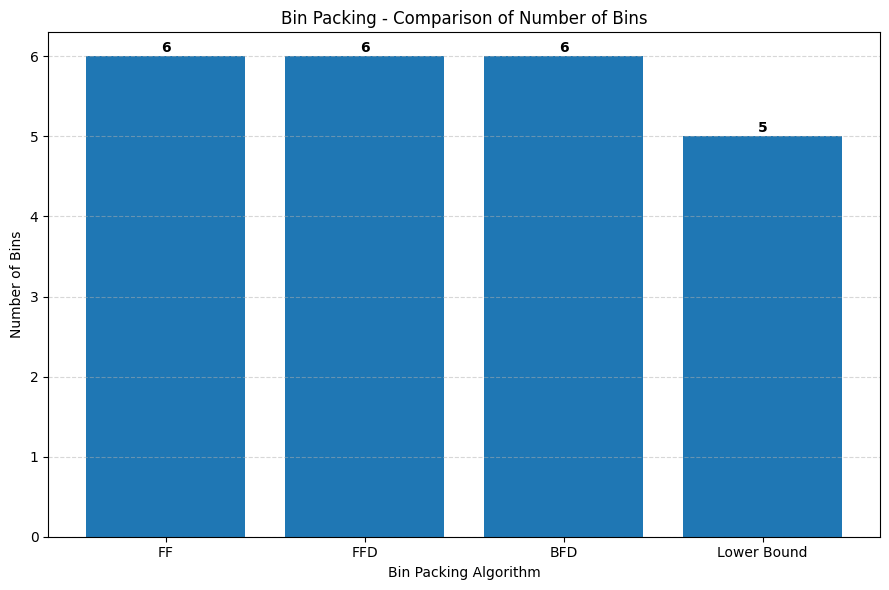

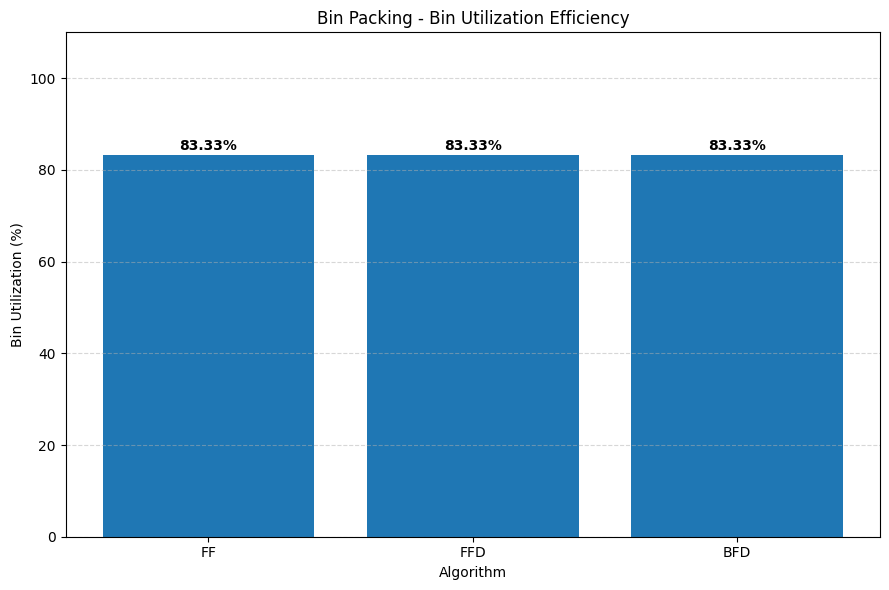

In [1]:
import matplotlib.pyplot as plt


# ==========================================
# FIRST FIT
# ==========================================

def first_fit(items, capacity=1.0):

    bins = []
    bin_contents = []

    for item in items:

        placed = False

        for i, space in enumerate(bins):

            if space >= item:

                bins[i] -= item
                bin_contents[i].append(item)

                placed = True
                break

        if not placed:

            bins.append(capacity - item)
            bin_contents.append([item])

    return bin_contents


# ==========================================
# FIRST FIT DECREASING
# ==========================================

def first_fit_decreasing(items, capacity=1.0):

    sorted_items = sorted(items, reverse=True)

    return first_fit(sorted_items, capacity)


# ==========================================
# BEST FIT DECREASING
# ==========================================

def best_fit_decreasing(items, capacity=1.0):

    sorted_items = sorted(items, reverse=True)

    bins = []
    bin_contents = []

    for item in sorted_items:

        best_idx = -1
        best_space = float('inf')

        for i, space in enumerate(bins):

            if space >= item and space - item < best_space:

                best_space = space - item
                best_idx = i

        if best_idx >= 0:

            bins[best_idx] -= item
            bin_contents[best_idx].append(item)

        else:

            bins.append(capacity - item)
            bin_contents.append([item])

    return bin_contents


# ==========================================
# DISPLAY BINS
# ==========================================

def display_bins(label, bins):

    print(f"\n{label}: {len(bins)} bins")

    for i, b in enumerate(bins, 1):

        used = sum(b)

        bar = '#' * int(used * 20)

        print(
            f" Bin {i}: "
            f"{[round(x, 1) for x in b]} "
            f"| Used: {used:.1f} "
            f"[{bar:<20}]"
        )


# ==========================================
# INPUT
# ==========================================

items = [
    0.5, 0.7, 0.3, 0.9, 0.2,
    0.6, 0.8, 0.4, 0.1, 0.5
]

capacity = 1.0


# ==========================================
# LOWER BOUND
# ==========================================

total = sum(items)

lower_bound = int(total // capacity)

if total % capacity != 0:
    lower_bound += 1


# ==========================================
# RUN ALGORITHMS
# ==========================================

ff_bins = first_fit(items, capacity)

ffd_bins = first_fit_decreasing(
    items,
    capacity
)

bfd_bins = best_fit_decreasing(
    items,
    capacity
)


# ==========================================
# BASIC INFORMATION
# ==========================================

print("\n==============================================")
print("       EFFICIENT BIN PACKING")
print("==============================================")

print("\nItems:", items)
print("Capacity:", capacity)
print("Sum of items:", total)
print("Lower Bound on bins:", lower_bound)


# ==========================================
# DISPLAY BIN CONTENTS
# ==========================================

display_bins(
    "First Fit (FF)",
    ff_bins
)

display_bins(
    "First Fit Decreasing (FFD)",
    ffd_bins
)

display_bins(
    "Best Fit Decreasing (BFD)",
    bfd_bins
)


# ==========================================
# TABLE
# ==========================================

print("\n")
print("==============================================")
print("              PERFORMANCE TABLE")
print("==============================================")

print(
    f"{'Algorithm':<25}"
    f"{'Bins Used':>12}"
    f"{'Lower Bound':>15}"
    f"{'Efficiency':>15}"
)

print("-" * 67)

algorithms = [
    ("First Fit (FF)", len(ff_bins)),
    ("First Fit Decreasing (FFD)", len(ffd_bins)),
    ("Best Fit Decreasing (BFD)", len(bfd_bins))
]

for name, bins_used in algorithms:

    efficiency = (
        total / (bins_used * capacity)
    ) * 100

    print(
        f"{name:<25}"
        f"{bins_used:>12}"
        f"{lower_bound:>15}"
        f"{efficiency:>14.2f}%"
    )

print("-" * 67)


# ==========================================
# GRAPH 1 - BINS USED
# ==========================================

names = [
    "FF",
    "FFD",
    "BFD",
    "Lower Bound"
]

values = [
    len(ff_bins),
    len(ffd_bins),
    len(bfd_bins),
    lower_bound
]


plt.figure(figsize=(9, 6))

bars = plt.bar(
    names,
    values
)

plt.xlabel("Bin Packing Algorithm")
plt.ylabel("Number of Bins")

plt.title(
    "Bin Packing - Comparison of Number of Bins"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)


# Add values on bars
for bar, value in zip(bars, values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

plt.show()


# ==========================================
# GRAPH 2 - BIN UTILIZATION
# ==========================================

efficiencies = []

for name, bins_used in algorithms:

    efficiency = (
        total / (bins_used * capacity)
    ) * 100

    efficiencies.append(efficiency)


plt.figure(figsize=(9, 6))

bars = plt.bar(
    ["FF", "FFD", "BFD"],
    efficiencies
)

plt.xlabel("Algorithm")
plt.ylabel("Bin Utilization (%)")

plt.title(
    "Bin Packing - Bin Utilization Efficiency"
)

plt.ylim(0, 110)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)


for bar, value in zip(bars, efficiencies):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

plt.show()